# Faster and more reliable FIxLIP approximation

We compare the new **ProxySHAP** approximation algorithm against the original version.

**ProxySHAP**:
1. Computes sparse interaction explanations including $0$ values for some indices.
2. Improves the reliability of approximation for larger models/games by
    - alleviating the $n < p$ problem in linear regression approximation,
    - requiring less CPU RAM to perform the computation.
3. Improves the faithfulness of approximation in low-budget regimes (requires fewer model inferences).

**Note**: This example requires the updated `fixlip_faster` environment, installed via `conda env create -f env_faster.yml`.

In [1]:
import os
from PIL import Image
from pathlib import Path
from copy import deepcopy

import torch
import shapiq
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModel

import src

## 1. Smaller model/game with a model-agnostic estimator

### load model

In [2]:
torch.set_float32_matmul_precision("high")
model = AutoModel.from_pretrained("google/siglip2-base-patch32-256")
model.to('cuda')
processor = AutoProcessor.from_pretrained("google/siglip2-base-patch32-256", use_fast=True)

### load data

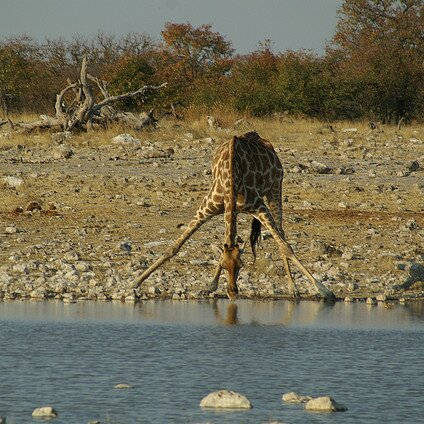

In [3]:
input_text = "a giraffe drinking water from a river"
input_image = Image.open("assets/giraffe_drinking.jpg")
input_image

### define game

In [4]:
game = src.game_huggingface.VisionLanguageGame(
    model=model,
    processor=processor,
    input_image=input_image,
    input_text=input_text,
    batch_size=64
)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

### define approximator

In [5]:
fixlip = src.fixlip.FIxLIP(n_players_image=n_players_image, n_players_text=n_players_text, random_state=0)

### compute explanations

Original implementation

In [6]:
# src.utils.set_seed(0)
# iv_original = fixlip.approximate(game, budget=2**12)

New implementation

In [7]:
src.utils.set_seed(0)
iv_proxyshap = fixlip.approximate(game, budget=2**12, approximation_type="proxyshap")

### compare explanations against a higher budget one

In [8]:
# src.utils.set_seed(0)
# iv_ground_truth = fixlip.approximate(game, budget=2**18)

Omit the baseline value stored in `values[0]` for the evaluation

In [9]:
# def mae(a, b):
#     return np.mean(np.abs(a - b))
# def correlation(a, b):
#     return sp.stats.spearmanr(a, b)[0]
# print(f'Difference between the original and proxyshap:\n'
#       f' MAE (↓): {mae(iv_original.values[1:], iv_proxyshap.values[1:]):.3f} CORR (↑): {correlation(iv_original.values[1:], iv_proxyshap.values[1:]):.3f}')
# print(f'Difference between the original and ground truth:\n'
#       f' MAE (↓): {mae(iv_original.values[1:], iv_ground_truth.values[1:]):.3f} CORR (↑): {correlation(iv_original.values[1:], iv_ground_truth.values[1:]):.3f}')
# print(f'Difference between proxyshap and ground truth:\n'
#       f' MAE (↓): {mae(iv_proxyshap.values[1:], iv_ground_truth.values[1:]):.3f} CORR (↑): {correlation(iv_proxyshap.values[1:], iv_ground_truth.values[1:]):.3f}')

### save explanation

In [10]:
# iv_proxyshap.save(Path(os.path.join("results", "giraffe_drinking_fixlip_siglip2_32.json")))

### visualize explanation

In [11]:
interaction_values = iv_proxyshap
# interaction_values = shapiq.InteractionValues.load("results/giraffe_drinking_fixlip_siglip2_32.json")
print(interaction_values)

InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=4096,
    n_players=71, baseline_value=-9.518726348876953,
    Top 10 interactions:
        (70,): 4.201147948663447
        (65,): 3.9159282286737236
        (67,): 2.7782288132561916
        (64, 66): 1.0408748719910363
        (9, 65): 1.0057041969803322
        (65, 70): -1.0021478672861122
        (66,): -1.1229631797639286
        (64, 65): -1.3482445481240575
        (67, 70): -2.0305947801971342
        (): -9.518726348876953
)


In [12]:
def denormalize(img, mean, std):
    return img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)

In [13]:
text_tokens = game.inputs.tokens()
text_tokens = text_tokens[0:game.n_players_text]
text_tokens = [token.replace('▁', '') for token in text_tokens]
assert len(text_tokens) == game.n_players_text
players_text = list(range(game.n_players_image, game.n_players))
assert game.n_players == iv_proxyshap.n_players == max(players_text) + 1
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed, 
    game.processor.image_processor.image_mean, 
    game.processor.image_processor.image_std
).permute(1, 2, 0).numpy()

This model 'sees' two giraffes in the image

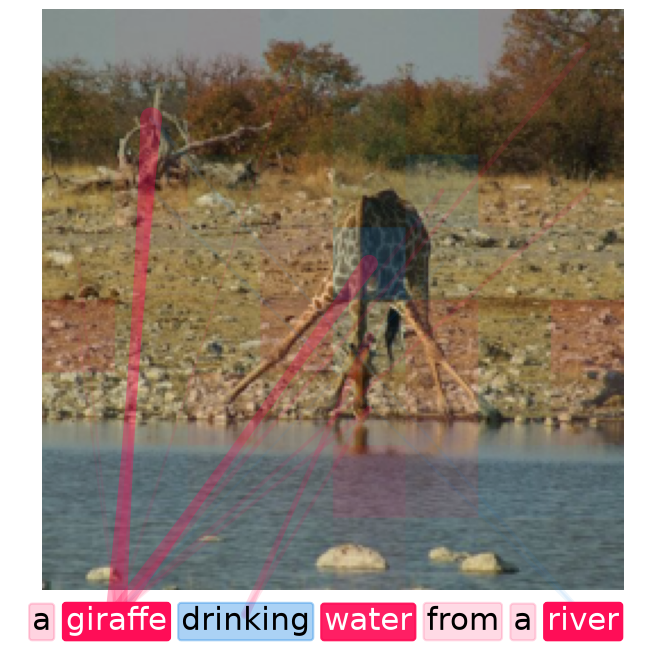

In [14]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=iv_proxyshap,
    plot_interactions=True,
    top_k=16,
    normalize_jointly=True,
    figsize=(6.5, 6.5),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
    max_value=3
)
plt.tight_layout(pad=0.15)
# plt.savefig("giraffe_drinking_fixlip_siglip2_32.pdf")

## 2. Larger model/game with the cross-modal estimator

### load model

In [15]:
torch.set_float32_matmul_precision("medium")
model = AutoModel.from_pretrained("google/siglip2-base-patch16-224")
model.to('cuda')
processor = AutoProcessor.from_pretrained("google/siglip2-base-patch16-224", use_fast=True)

### load data

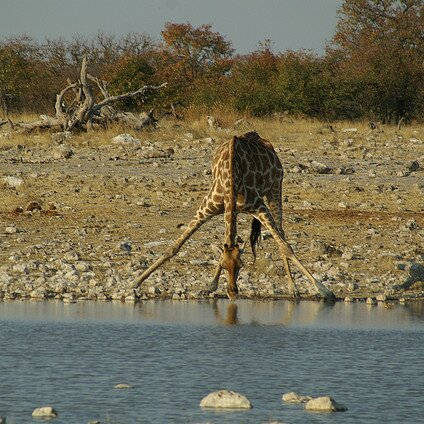

In [16]:
input_text = "a giraffe drinking water from a river"
input_image = Image.open("assets/giraffe_drinking.jpg")
input_image

### define game

In [17]:
game = src.game_huggingface.VisionLanguageGame(
    model=model,
    processor=processor,
    input_image=input_image,
    input_text=input_text,
    batch_size=64
)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

### define approximator

In [18]:
fixlip = src.fixlip.FIxLIP(n_players_image=n_players_image, n_players_text=n_players_text, random_state=0)

### compute explanation

In [19]:
proxy_xgboost_hyperparameters = {
    "n_estimators": 2000,
    "learning_rate": 0.05,
    "max_depth": 5,
    "reg_lambda": 10
}

In [20]:
src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(
    game=game, 
    budget_text=2**5, 
    budget_image=2**13, 
    approximation_type="proxyshap",
    **proxy_xgboost_hyperparameters
)

### save explanation

In [21]:
# interaction_values.save(Path(os.path.join("results", "giraffe_drinking_fixlip_siglip2_16.json")))

### analyze explanation

In [22]:
# interaction_values = shapiq.InteractionValues.load("results/giraffe_drinking_fixlip_siglip2_16.json")
print(interaction_values)

InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=262144,
    n_players=203, baseline_value=-9.123275756835938,
    Top 10 interactions:
        (197,): 5.638827118347526
        (202,): 2.1621787595296773
        (77, 197): 1.7479348606017227
        (78, 197): 1.607254707392721
        (199,): 1.5139913505940772
        (196, 198): 1.3209405277868882
        (196, 197): -1.8037477833713638
        (199, 202): -1.8942822166777589
        (197, 200): -1.9553605794871085
        (): -9.123275756835938
)


helper objects

In [23]:
def denormalize(img, mean, std):
    return img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
text_tokens = game.inputs.tokens()
text_tokens = text_tokens[0:game.n_players_text]
text_tokens = [token.replace('▁', '') for token in text_tokens]
assert len(text_tokens) == game.n_players_text
players_text = list(range(game.n_players_image, game.n_players))
assert game.n_players == interaction_values.n_players == max(players_text) + 1
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed, 
    game.processor.image_processor.image_mean, 
    game.processor.image_processor.image_std
).permute(1, 2, 0).numpy()

This model 'sees' a single giraffe in the image

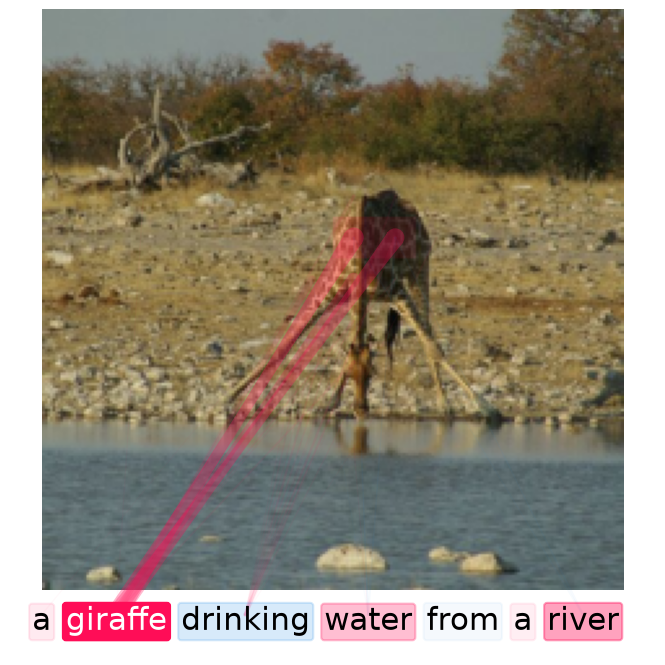

In [24]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(game.n_players_image)),
    iv=interaction_values,
    plot_interactions=True,
    top_k=30,
    normalize_jointly=True,
    figsize=(6.5, 6.5),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False
)
plt.tight_layout(pad=0.15)
# plt.savefig("giraffe_drinking_fixlip_siglip2_16.pdf")

retrieve first-order attributions to filter the graph via single token importance

In [25]:
attribution_values = src.utils.convert_iv_to_first_order(interaction_values)

In [26]:
av_text = src.utils.get_subset(attribution_values, players=players_text)
av_image = src.utils.get_subset(attribution_values, players=list(range(n_players_image)))

visualize text interactions with the most important image tokens

In [27]:
def plot_image_token(image, id_token, grid_size=14, patch_size=16):
    id_row = (id_token // grid_size)
    id_col = id_token % grid_size
    print(f'Image token {id_token} from row: {id_row}, column: {id_col}')
    input_token = image[(id_row * patch_size):((id_row + 1) * patch_size), (id_col * patch_size):((id_col + 1) * patch_size), :]
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.imshow(input_token)
    ax.axis("off")
    plt.tight_layout()
    return fig

In [28]:
k_most_important_tokens_image = 5
id_most_important_tokens_image = np.argpartition(av_image.values[:n_players_image], -k_most_important_tokens_image)[-k_most_important_tokens_image:][::-1]

Image token 77 from row: 5, column: 7


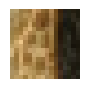

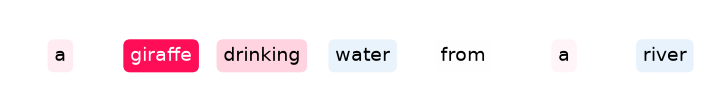

Image token 78 from row: 5, column: 8


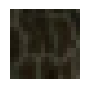

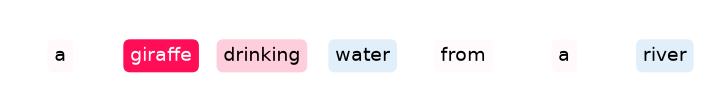

Image token 91 from row: 6, column: 7


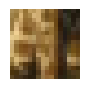

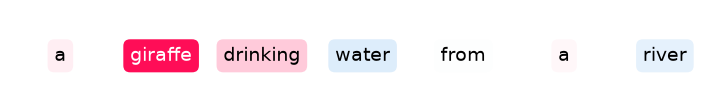

Image token 90 from row: 6, column: 6


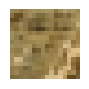

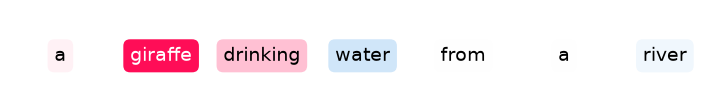

Image token 105 from row: 7, column: 7


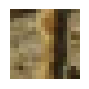

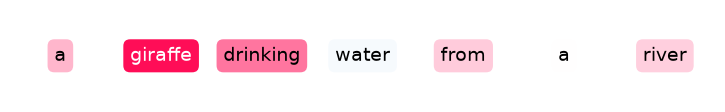

In [29]:
for id_token_image in id_most_important_tokens_image:
    text_interactions = deepcopy(av_text)
    for i, id_token_text in enumerate(players_text):
        text_interactions[i] = interaction_values.dict_values[(id_token_image, id_token_text)]
    plot_image_token(input_image_denormalized, id_token_image)
    src.plot.plot_sentence(text_interactions, sentence=text_tokens)
    plt.show()

visualize a subgraph for a subset of players (clique)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


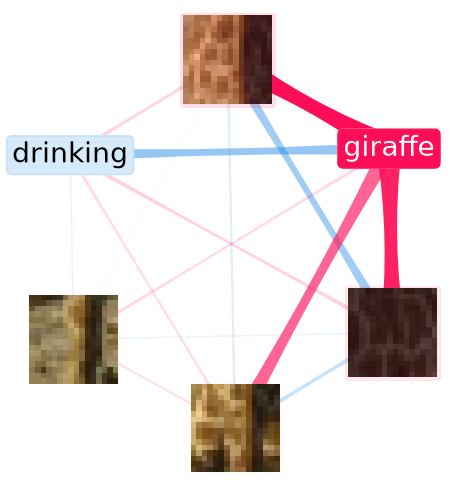

In [30]:
clique = {77, 78, 91, 105, 197, 198}
_ = src.plot.plot_interaction_subset(
    interaction_values,
    clique = clique,
    image_players = list(range(game.n_players_image)),
    img = input_image_denormalized,
    text = text_tokens,
    fontsize = 20,
    image_size = 2,
    edges_size = 3,
    figsize = (5, 5)
)